# ART Attack Detection
This notebook demonstrates canonical ART attack workflows using deckard abstractions:

- Evasion with `FastGradientMethod` on sklearn logistic regression
The data/model/attack settings mirror the canonical examples used in the attack notebook.

## Optional Dependencies

This notebook includes detector workflows with torch-based model support.

Recommended extras:

- `torch`

Install from repository root:

```bash
pip install -e '.[torch]'
```

In [1]:
# !pip install -e '.[torch]'

In [2]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from deckard.attack import AttackConfig
from deckard.data import DataConfig
from deckard.model import ModelConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", palette="colorblind")

NOTEBOOK_ROOT = Path(".")
ARTIFACT_DIR = NOTEBOOK_ROOT / "build" / "detector"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Artifacts will be written under: {ARTIFACT_DIR}")


def plot_clean_vs_attack(df, title):
    plot_df = df.melt(
        id_vars=["example", "attack_subtype"],
        value_vars=["clean_accuracy", "attack_accuracy"],
        var_name="metric_label",
        value_name="metric_value",
    )
    plt.figure(figsize=(8, 4.5))
    sns.barplot(data=plot_df, x="example", y="metric_value", hue="metric_label")
    plt.ylim(0, 1)
    plt.title(title)
    plt.xlabel("Example")
    plt.ylabel("Accuracy")
    plt.tight_layout()
    plt.show()

/Users/c.meyers/.pyenv/versions/3.10.20/envs/deckard/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Artifacts will be written under: build/detector


## Canonical Evasion Example

This section uses sklearn logistic regression on `make_classification` and applies ART `FastGradientMethod` through `AttackConfig`.

,example,attack_family,attack_subtype,clean_accuracy,attack_accuracy,attack_size,attack_generation_time,attack_prediction_time,attack_score_time
0,sklearn_logistic_fgm,evasion,FastGradientMethod,1.0,1.0,24.0,0.000503,0.00005,0.002089


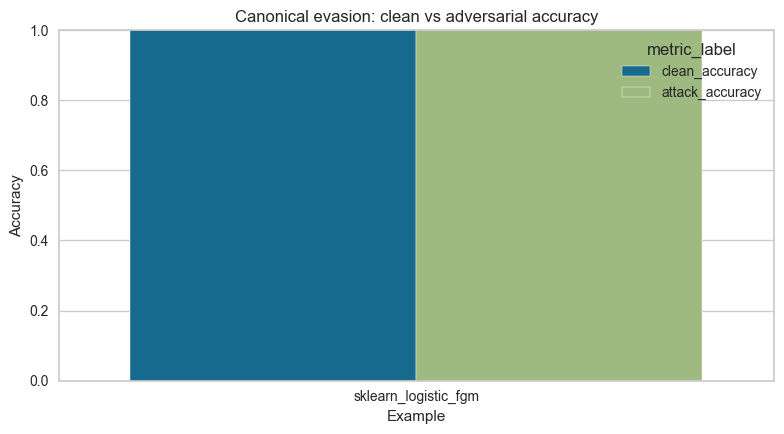

In [3]:
evasion_data = DataConfig(
    dataset_name="make_classification",
    data_params={
        "n_samples": 220,
        "n_features": 10,
        "n_informative": 6,
        "n_redundant": 0,
        "n_clusters_per_class": 1,
        "n_classes": 2,
        "class_sep": 1.4,
        "random_state": SEED,
    },
    train_size=160,
    test_size=60,
    random_state=SEED,
    stratify=True,
    classifier=True,
)
evasion_data()

evasion_model = ModelConfig(
    model_type="sklearn.linear_model.LogisticRegression",
    classifier=True,
    model_params={"max_iter": 300},
)
evasion_model(evasion_data)

evasion_attack = AttackConfig(
    attack_type="art.attacks.evasion.FastGradientMethod",
    attack_params={
        "eps": 0.15,
        "eps_step": 0.05,
        "norm": "inf",
        "targeted": False,
        "minimal": False,
    },
    attack_size=24,
)

evasion_scores = evasion_attack(data=evasion_data, model=evasion_model)
evasion_df = pd.DataFrame(
    [
        {
            "example": "sklearn_logistic_fgm",
            "attack_family": "evasion",
            "attack_subtype": "FastGradientMethod",
            "clean_accuracy": float(evasion_scores["benign_accuracy"]),
            "attack_accuracy": float(evasion_scores["evasion_accuracy"]),
            "attack_size": float(evasion_scores["attack_size"]),
            "attack_generation_time": float(evasion_scores["attack_generation_time"]),
            "attack_prediction_time": float(evasion_scores["attack_prediction_time"]),
            "attack_score_time": float(evasion_scores["attack_score_time"]),
        }
    ]
)

display(evasion_df)
plot_clean_vs_attack(evasion_df, "Canonical evasion: clean vs adversarial accuracy")

## Canonical Poisoning Example

This section uses sklearn `SVC` and ART `PoisoningAttackSVM` through `AttackConfig`, matching the canonical poisoning workflow.

,example,attack_family,attack_subtype,clean_accuracy,attack_accuracy,attack_size,attack_generation_time,attack_prediction_time,attack_score_time
0,sklearn_svc_poisoning_svm,poisoning,PoisoningAttackSVM,0.908,0.908,6.0,1.936893,0.001785,0.004267


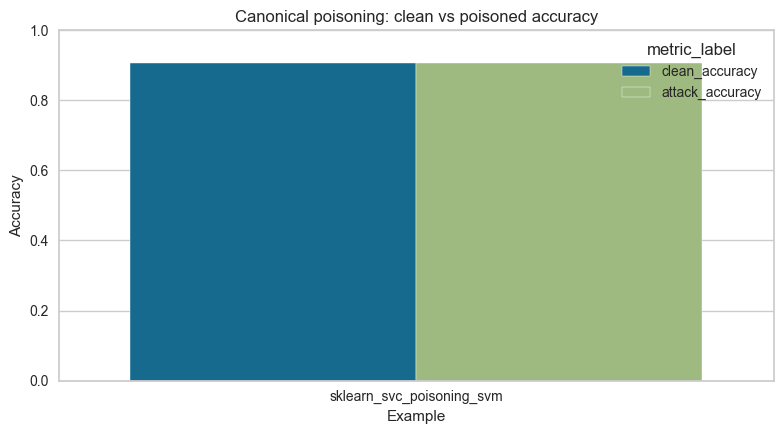

In [4]:
poison_data = DataConfig(
    dataset_name="make_classification",
    data_params={
        "n_samples": 180,
        "n_features": 8,
        "n_informative": 6,
        "n_redundant": 0,
        "n_clusters_per_class": 1,
        "n_classes": 2,
        "class_sep": 1.2,
        "random_state": SEED + 10,
    },
    train_size=120,
    test_size=60,
    random_state=SEED + 10,
    stratify=True,
    classifier=True,
)
poison_data()

poison_model = ModelConfig(
    model_type="sklearn.svm.SVC",
    classifier=True,
    model_params={"kernel": "linear", "probability": True, "C": 1.0},
)
poison_model(poison_data)

poison_attack = AttackConfig(
    attack_type="art.attacks.poisoning.PoisoningAttackSVM",
    attack_params={"step": 0.05, "eps": 0.2, "max_iter": 2, "verbose": False},
    attack_size=6,
)

poison_scores = poison_attack(data=poison_data, model=poison_model)
poison_df = pd.DataFrame(
    [
        {
            "example": "sklearn_svc_poisoning_svm",
            "attack_family": "poisoning",
            "attack_subtype": "PoisoningAttackSVM",
            "clean_accuracy": float(poison_scores["benign_accuracy"]),
            "attack_accuracy": float(poison_scores["poisoned_accuracy"]),
            "attack_size": float(poison_scores["attack_size"]),
            "attack_generation_time": float(poison_scores["attack_generation_time"]),
            "attack_prediction_time": float(poison_scores["attack_prediction_time"]),
            "attack_score_time": float(poison_scores["attack_score_time"]),
        }
    ]
)

display(poison_df)
plot_clean_vs_attack(poison_df, "Canonical poisoning: clean vs poisoned accuracy")

## Summary

The table below consolidates both canonical examples and writes a CSV artifact for downstream comparison.

In [5]:
summary_df = pd.concat([evasion_df, poison_df], ignore_index=True)
display(summary_df)

summary_df.to_csv(ARTIFACT_DIR / "canonical_attack_examples.csv", index=False)
print(f"Saved summary to: {ARTIFACT_DIR / 'canonical_attack_examples.csv'}")

,example,attack_family,attack_subtype,clean_accuracy,attack_accuracy,attack_size,attack_generation_time,attack_prediction_time,attack_score_time
0,sklearn_logistic_fgm,evasion,FastGradientMethod,1.000,1.000,24.0,0.000503,0.000050,0.002089
1,sklearn_svc_poisoning_svm,poisoning,PoisoningAttackSVM,0.908,0.908,6.0,1.936893,0.001785,0.004267


Saved summary to: build/detector/canonical_attack_examples.csv
